# Interactive Posterior Visualization

This notebook loads an InferenceModel from a checkpoint and creates interactive posterior plots with contour lines, similar to PlotPosteriorCallBack. The grid resolution can be adjusted on the fly using interactive widgets.


## 1. Import Required Libraries

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, VBox, HBox, Output, FloatText
import ipywidgets as widgets
from torch.utils.data import DataLoader, Subset

# Import from pembhb
from src.pembhb.model import InferenceNetwork
from src.pembhb.data import MBHBDataset
from src.pembhb.utils import (
    _ORDERED_PRIOR_KEYS, 
    get_logratios_grid_2d, 
    contour_levels, 
    posterior_contours_2d,
    mbhb_collate_fn
)
from pembhb import ROOT_DIR

%matplotlib widget
print("Libraries imported successfully!")

ROOT_DIR: /u/g/gpuleo/pembhb
ROOT_DIR: /u/g/gpuleo/pembhb
Libraries imported successfully!


## 2. Load InferenceModel from Checkpoint

In [2]:
# Path to your checkpoint - update this path to your specific checkpoint
checkpoint_path = "/data/gpuleo/mbhb/logs/20260206withsky_v1_round_4/version_0/checkpoints/epoch=287-step=40320.ckpt"

# Load the model
print(f"Loading model from: {checkpoint_path}")
model = InferenceNetwork.load_from_checkpoint(checkpoint_path)
model.eval()  # Set to evaluation mode
model = model.to("cuda" if torch.cuda.is_available() else "cpu")

print(f"Model loaded successfully!")
print(f"Model device: {next(model.parameters()).device}")
print(f"Available marginals: {model.output_names}")

Loading model from: /data/gpuleo/mbhb/logs/20260206withsky_v1_round_4/version_0/checkpoints/epoch=287-step=40320.ckpt
Parameter mean: torch.Size([11])
Parameter std: torch.Size([11])
Model loaded successfully!
Model device: cuda:0
Available marginals: ['logMchirp_q', 'lambda_beta']


/u/g/gpuleo/miniconda3/envs/lisa/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'data_summarizer' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['data_summarizer'])`.


## 3. Load and Prepare Data

In [3]:
# Path to your observation data - update this path
data_path = "/data/gpuleo/mbhb/observation_skyloc.h5"  # Example: "observation_fix_all_notmcq_newdata.h5"

# Load dataset and create dataloader
print(f"Loading data from: {data_path}")
dataset_observation = MBHBDataset(data_path, cache_in_memory=True)
dataset_subset = Subset(dataset_observation, indices=[0])  # Take the first observation

# Create dataloader
batch_size = 1
noise_factor = 1.0  # Adjust as needed
dataloader_obs = DataLoader(
    dataset_subset, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=lambda b: mbhb_collate_fn(b, dataset_subset, noise_shuffling=False, noise_factor=noise_factor)
)

print(f"Data loaded successfully!")
print(f"Dataset size: {len(dataset_observation)}")
print(f"Using observation index: 0")


batch = next(iter(dataloader_obs))
print("Batch keys:", batch.keys())
print(batch["source_parameters"])

Loading data from: /data/gpuleo/mbhb/observation_skyloc.h5
Data loaded successfully!
Dataset size: 1
Using observation index: 0
Batch keys: dict_keys(['source_parameters', 'wave_fd', 'wave_td', 'noise_fd', 'noise_td', 'noise_index'])
tensor([[ 5.2500e+00,  4.6798e+00,  0.0000e+00,  0.0000e+00,  1.0000e+03,
          0.0000e+00,  5.0000e-01,  3.1400e+00,  5.0000e-01,  1.0000e+00,
         -2.0000e+00]])


## 4. Define Plotting Function

This function replicates the plotting logic from PlotPosteriorCallBack, generating 2D posterior distribution plots with contour lines.

In [4]:
def plot_posterior_2d(dataloader, model, in_param_idx, out_param_idx, 
                      ngrid_points=100, bounds_0=None, bounds_1=None,
                      figsize=(8, 7), show_diagnostics=True, show_proposal_box=True):
    """
    Plot 2D posterior with contour lines, similar to PlotPosteriorCallBack.
    
    Parameters:
    -----------
    dataloader : DataLoader
        DataLoader containing the observation data
    model : InferenceNetwork
        Trained inference model
    in_param_idx : tuple
        Tuple of parameter indices (e.g., (0, 1) for logMchirp and q)
    out_param_idx : int
        Output index corresponding to this marginal
    ngrid_points : int
        Number of grid points in each dimension
    bounds_0 : tuple, optional
        Custom bounds for first parameter (min, max)
    bounds_1 : tuple, optional
        Custom bounds for second parameter (min, max)
    figsize : tuple
        Figure size
    show_diagnostics : bool
        Whether to print diagnostic information about boxes and contours
    show_proposal_box : bool
        Whether to overlay the proposal box (widest contour box) as a rectangle
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    ax : matplotlib.axes.Axes
        The axes object
    boxes : list
        List of bounding boxes for each contour level (xmin, xmax, ymin, ymax)
    levels : np.array
        The contour levels used
    labels : np.array
        The probability labels for each level
    """
    from matplotlib.patches import Rectangle
    
    # Get logratios on grid
    print(f"Computing logratios on {ngrid_points}x{ngrid_points} grid...")
    logratios, inj_params, gx, gy = get_logratios_grid_2d(
        dataloader,
        model,
        ngrid_points=ngrid_points,
        in_param_idx=in_param_idx,
        out_param_idx=out_param_idx,
        bounds_0=bounds_0,
        bounds_1=bounds_1
    )
    
    # Convert to ratios and normalize
    # With xy indexing: gx varies along columns (axis 1), gy varies along rows (axis 0)
    ratios = np.exp(logratios)
    dp1 = gx[0, 1] - gx[0, 0]  # param_0 spacing (x varies along columns)
    dp2 = gy[1, 0] - gy[0, 0]  # param_1 spacing (y varies along rows)
    norm2d = ratios / np.sum(ratios * dp1 * dp2, axis=(1, 2), keepdims=True)
    
    # Compute contour levels
    levels, labels = contour_levels(norm2d)
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Get parameter names
    param_name_0 = _ORDERED_PRIOR_KEYS[in_param_idx[0]]
    param_name_1 = _ORDERED_PRIOR_KEYS[in_param_idx[1]]
    
    # Plot using posterior_contours_2d
    boxes = None
    try:
        boxes = posterior_contours_2d(
            gx,
            gy,
            norm2d[0],
            inj_params[0],
            ax_buffer=ax,
            parameter_names=[param_name_0, param_name_1],
            title=f"Posterior: {param_name_0} vs {param_name_1}",
            levels=levels,
            levels_labels=labels,
            do_plot=True
        )
        print(f"Plot generated successfully! Grid: {ngrid_points}x{ngrid_points}")
        
        # Overlay the proposal box (widest box)
        if show_proposal_box and boxes is not None and len(boxes) > 0:
            widest_box = boxes[0]  # Last box is the widest (level 0)
            # widest_box format: [xmin, xmax, ymin, ymax]
            x_min, x_max, y_min, y_max = widest_box
            width = x_max - x_min
            height = y_max - y_min
            
            # Create rectangle patch
            rect = Rectangle(
                (x_min, y_min), 
                width, 
                height,
                linewidth=2.5,
                edgecolor='red',
                facecolor='none',
                linestyle='--',
                label='Proposal Box',
                zorder=10  # Make sure it's on top
            )
            ax.add_patch(rect)
            ax.legend(loc='best')
        
        if show_diagnostics and boxes is not None:
            print(f"\n=== Contour Diagnostics ===")
            print(f"Number of contour levels: {len(levels)}")
            print(f"Injected parameters: {param_name_0}={inj_params[0][0]:.6f}, {param_name_1}={inj_params[0][1]:.6f}")
            print(f"\nContour Boxes (sorted from narrowest to widest):")
            for i, (box, level, label) in enumerate(zip(boxes, levels, labels)):
                print(f"  Level {i}: probability={label:.4f}, level_value={level:.6e}")
                print(f"    {param_name_0}: [{box[0]:.6f}, {box[1]:.6f}] (width: {box[1]-box[0]:.6f})")
                print(f"    {param_name_1}: [{box[2]:.6f}, {box[3]:.6f}] (width: {box[3]-box[2]:.6f})")
            
            # Highlight the widest box (used for prior updating in TMNRE)
            widest_box = boxes[0]
            print(f"\n*** WIDEST BOX (used for prior updating) ***")
            print(f"  {param_name_0}: [{widest_box[0]:.6f}, {widest_box[1]:.6f}]")
            print(f"  {param_name_1}: [{widest_box[2]:.6f}, {widest_box[3]:.6f}]")
            
    except ValueError as ve:
        print(f"Error during plotting: {ve}")
        boxes = None
        
    plt.tight_layout()
    return fig, ax, boxes, levels, labels

## 4b. Corner Plot Function with 1D Marginals

Create a corner plot that shows both the 2D posterior and the 1D marginals obtained by marginalizing (summing) over one parameter.

In [ ]:
def plot_corner_with_marginals(dataloader, model, in_param_idx, out_param_idx, 
                               ngrid_points=100, bounds_0=None, bounds_1=None,
                               figsize=(6, 6), show_diagnostics=False, results_mcmc=None):
    """
    Create a corner plot with 2D posterior and 1D marginals.
    
    The 1D marginals are computed by marginalizing (integrating/summing) the 2D posterior
    along the appropriate axis.
    
    With xy indexing: norm2d[i, j] corresponds to (param_0=grid_0[j], param_1=grid_1[i])
      - axis 0 = param_1 (y), axis 1 = param_0 (x)
    
    Parameters:
    -----------
    dataloader : DataLoader
        DataLoader containing the observation data
    model : InferenceNetwork
        Trained inference model
    in_param_idx : tuple
        Tuple of parameter indices (e.g., (0, 1) for logMchirp and q)
    out_param_idx : int
        Output index corresponding to this marginal
    ngrid_points : int
        Number of grid points in each dimension
    bounds_0 : tuple, optional
        Custom bounds for first parameter (min, max)
    bounds_1 : tuple, optional
        Custom bounds for second parameter (min, max)
    figsize : tuple
        Figure size
    show_diagnostics : bool
        Whether to print diagnostic information
    results_mcmc : pd.DataFrame, optional
        DataFrame with MCMC samples (columns = parameter names from _ORDERED_PRIOR_KEYS)
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The figure object
    axs : dict
        Dictionary with keys '2d', 'marginal_0', 'marginal_1' pointing to axes
    data : dict
        Dictionary containing grid data, posteriors, and marginals
    """
    from matplotlib.patches import Rectangle
    from scipy.stats import gaussian_kde
    
    # Get logratios on grid
    print(f"Computing logratios on {ngrid_points}x{ngrid_points} grid...")
    logratios, inj_params, gx, gy = get_logratios_grid_2d(
        dataloader,
        model,
        ngrid_points=ngrid_points,
        in_param_idx=in_param_idx,
        out_param_idx=out_param_idx,
        bounds_0=bounds_0,
        bounds_1=bounds_1
    )
    
    # Convert to ratios and normalize the 2D posterior
    # With xy indexing: gx varies along columns (axis 1), gy varies along rows (axis 0)
    ratios = np.exp(logratios)
    dp1 = gx[0, 1] - gx[0, 0]  # param_0 spacing (x varies along columns)
    dp2 = gy[1, 0] - gy[0, 0]  # param_1 spacing (y varies along rows)
    norm2d = ratios / np.sum(ratios * dp1 * dp2, axis=(1, 2), keepdims=True)
    
    # Extract 1D grid vectors
    # With xy indexing: x values from any row, y values from any column
    grid_0 = gx[0, :]  # param_0 (x) values, shape (ngrid,)
    grid_1 = gy[:, 0]  # param_1 (y) values, shape (ngrid,)
    
    # Compute 1D marginals by integrating over the other parameter
    # With xy indexing: norm2d[i, j] has axis 0 = param_1, axis 1 = param_0
    # p(param_0) = integrate over param_1 → sum over axis 0 (rows)
    # p(param_1) = integrate over param_0 → sum over axis 1 (columns)
    marginal_0 = np.sum(norm2d[0] * dp2, axis=0)  # p(param_0), shape (ngrid,)
    marginal_1 = np.sum(norm2d[0] * dp1, axis=1)  # p(param_1), shape (ngrid,)
    
    # Verify normalization (should be close to 1)
    norm_check_0 = np.sum(marginal_0 * dp1)
    norm_check_1 = np.sum(marginal_1 * dp2)
    
    if show_diagnostics:
        print(f"Marginal normalization check:")
        print(f"  Marginal 0 integral: {norm_check_0:.6f}")
        print(f"  Marginal 1 integral: {norm_check_1:.6f}")
    
    # Compute contour levels for 2D plot
    levels, labels = contour_levels(norm2d)
    
    # Get parameter names
    param_name_0 = _ORDERED_PRIOR_KEYS[in_param_idx[0]]
    param_name_1 = _ORDERED_PRIOR_KEYS[in_param_idx[1]]
    
    # Create corner plot layout with constrained layout to handle colorbar
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    
    # Define grid layout: 
    # [marginal_0 on top] [empty]
    # [2D plot]            [marginal_1 on right]
    gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                          hspace=0.05, wspace=0.05)
    
    ax_2d = fig.add_subplot(gs[1, 0])
    ax_marg_right = fig.add_subplot(gs[1, 1], sharey=ax_2d)
    ax_marg_top = fig.add_subplot(gs[0, 0], sharex=ax_2d)
    
    # Set white background
    ax_2d.set_facecolor('white')
    
    # Plot NRE contours with different linestyles (no colormap)
    # Define linestyles for the 4 contour levels: solid, dash, dash-dot, dot
    linestyles_nre = ['-', '--', '-.', ':']
    
    try:
        from pembhb.utils import contour_boxes
        # Plot each NRE contour level individually with specific linestyle
        boxes_list = []
        for i, (level, linestyle) in enumerate(zip(levels, linestyles_nre)):
            box, cs = contour_boxes(gx, gy, norm2d[0], [level], ax=ax_2d, 
                                   colors='blue', linewidths=2, linestyles=linestyle)
            boxes_list.extend(box)
            if i == 0:  # Label only the first set
                fmt = {level: f"{labels[i]:.3f}"}
                ax_2d.clabel(cs, fmt=fmt, fontsize=8)
        boxes = boxes_list
    except Exception as e:
        print(f"Warning: Could not plot NRE contours: {e}")
        boxes = None
    
    # Plot MCMC contours if provided
    mcmc_samples_0 = None
    mcmc_samples_1 = None
    
    if results_mcmc is not None:
        param_name_0 = _ORDERED_PRIOR_KEYS[in_param_idx[0]]
        param_name_1 = _ORDERED_PRIOR_KEYS[in_param_idx[1]]
        
        # Extract MCMC samples for these parameters
        mcmc_samples_0 = results_mcmc[param_name_0].values
        mcmc_samples_1 = results_mcmc[param_name_1].values
        
        # Compute 2D KDE on the same grid as NRE
        try:
            kde_2d = gaussian_kde(np.vstack([mcmc_samples_0, mcmc_samples_1]))
            grid_0_1d = gx[0, :]
            grid_1_1d = gy[:, 0]
            grid_mesh = np.vstack([gx.ravel(), gy.ravel()])
            mcmc_density = kde_2d(grid_mesh).reshape(gx.shape)
            
            # Normalize MCMC density to match NRE normalization
            dp1 = gx[0, 1] - gx[0, 0]
            dp2 = gy[1, 0] - gy[0, 0]
            mcmc_norm2d = mcmc_density / np.sum(mcmc_density * dp1 * dp2)
            
            # Compute contour levels for MCMC (same probability levels as NRE)
            mcmc_levels, mcmc_labels = contour_levels(mcmc_norm2d[None, :, :])
            
            # Plot MCMC contours in orange with different linestyles
            linestyles_mcmc = ['-', '--', '-.', ':']
            for i, (level, linestyle) in enumerate(zip(mcmc_levels, linestyles_mcmc)):
                box_mcmc, cs_mcmc = contour_boxes(gx, gy, mcmc_norm2d, [level], ax=ax_2d,
                                                   colors='orange', linewidths=2, linestyles=linestyle)
                if i == 0:  # Label only the first set
                    fmt_mcmc = {level: f"{mcmc_labels[i]:.3f}"}
                    ax_2d.clabel(cs_mcmc, fmt=fmt_mcmc, fontsize=8)
            
        except Exception as e:
            print(f"Warning: Could not compute MCMC contours: {e}")
            import traceback
            traceback.print_exc()
    
    # Mark true values
    ax_2d.axvline(x=inj_params[0][0], color='r', linestyle='--', linewidth=2, label='True Value')
    ax_2d.axhline(y=inj_params[0][1], color='r', linestyle='--', linewidth=2)
    
    ax_2d.set_xlabel(param_name_0, fontsize=12)
    ax_2d.set_ylabel(param_name_1, fontsize=12)
    ax_2d.grid(alpha=0.3)
    
    # Add legend for NRE vs MCMC
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color='blue', lw=2, label='NRE Posterior')]
    if results_mcmc is not None:
        legend_elements.append(Line2D([0], [0], color='orange', lw=2, label='MCMC Posterior'))
    legend_elements.append(Line2D([0], [0], color='r', ls='--', lw=2, label='True Value'))
    ax_2d.legend(handles=legend_elements, loc='best')
    
    # Plot 1D marginal for param_1 on the right (y-axis of 2D plot)
    ax_marg_right.plot(marginal_1, grid_1, 'b-', linewidth=2, label='NRE')
    ax_marg_right.fill_betweenx(grid_1, 0, marginal_1, alpha=0.3, color='b')
    
    # Add MCMC marginal if available
    if mcmc_samples_1 is not None:
        # Compute KDE for 1D marginal
        kde_1 = gaussian_kde(mcmc_samples_1)
        mcmc_marginal_1 = kde_1(grid_1)
        # Normalize
        mcmc_marginal_1 = mcmc_marginal_1 / np.sum(mcmc_marginal_1 * dp2)
        ax_marg_right.plot(mcmc_marginal_1, grid_1, 'orange', linewidth=2, label='MCMC')
        ax_marg_right.fill_betweenx(grid_1, 0, mcmc_marginal_1, alpha=0.3, color='orange')
    
    ax_marg_right.axhline(y=inj_params[0][1], color='r', linestyle='--', linewidth=2)
    ax_marg_right.set_xlabel('Density', fontsize=10)
    ax_marg_right.tick_params(labelleft=False)
    ax_marg_right.grid(alpha=0.3)
    
    # Plot 1D marginal for param_0 on top (x-axis of 2D plot)
    ax_marg_top.plot(grid_0, marginal_0, 'b-', linewidth=2, label='NRE')
    ax_marg_top.fill_between(grid_0, 0, marginal_0, alpha=0.3, color='b')
    
    # Add MCMC marginal if available
    if mcmc_samples_0 is not None:
        kde_0 = gaussian_kde(mcmc_samples_0)
        mcmc_marginal_0 = kde_0(grid_0)
        # Normalize
        mcmc_marginal_0 = mcmc_marginal_0 / np.sum(mcmc_marginal_0 * dp1)
        ax_marg_top.plot(grid_0, mcmc_marginal_0, 'orange', linewidth=2, label='MCMC')
        ax_marg_top.fill_between(grid_0, 0, mcmc_marginal_0, alpha=0.3, color='orange')
    ax_marg_top.axvline(x=inj_params[0][0], color='r', linestyle='--', linewidth=2)
    ax_marg_top.set_ylabel('Density', fontsize=10)
    ax_marg_top.tick_params(labelbottom=False)
    ax_marg_top.grid(alpha=0.3)
    
    print(f"Corner plot generated successfully! Grid: {ngrid_points}x{ngrid_points}")
    
    # Package data for return
    axs = {
        '2d': ax_2d,
        'marginal_right': ax_marg_right,
        'marginal_top': ax_marg_top
    }
    
    data = {
        'grid_x': gx,
        'grid_y': gy,
        'grid_0': grid_0,
        'grid_1': grid_1,
        'norm2d': norm2d[0],
        'marginal_0': marginal_0,
        'marginal_1': marginal_1,
        'inj_params': inj_params[0],
        'levels': levels,
        'labels': labels,
        'boxes': boxes
    }
    
    return fig, axs, data

## 5. Interactive Widget for Grid Evaluation

Create an interactive interface with sliders to adjust grid resolution, select parameters, and customize bounds on the fly.

In [29]:
# Create parameter selection dropdowns
param_options = [(name, idx) for idx, name in enumerate(_ORDERED_PRIOR_KEYS)]

# Find which marginals are available in the model
available_marginals = []
for idx, marginal in enumerate(model.marginals_list):
    if len(marginal) == 2:  # Only 2D marginals
        available_marginals.append((
            f"{_ORDERED_PRIOR_KEYS[marginal[0]]} vs {_ORDERED_PRIOR_KEYS[marginal[1]]}",
            (tuple(marginal), idx)
        ))

print("Available 2D marginals:")
for name, _ in available_marginals:
    print(f"  - {name}")
    
if not available_marginals:
    print("No 2D marginals found in the model!")

Available 2D marginals:
  - logMchirp vs q
  - lambda vs beta


In [30]:
def create_interactive_plot():
    """
    Create an interactive plot with widgets to control grid resolution and parameter selection.
    """
    # Output widget to hold the plot
    output = Output()
    
    # Storage for the latest results (for inspection)
    plot_results = {}
    
    # Widgets for parameter selection
    marginal_dropdown = Dropdown(
        options=available_marginals,
        description='Marginal:',
        style={'description_width': 'initial'}
    )
    
    # Grid resolution slider
    grid_slider = IntSlider(
        value=50,
        min=20,
        max=200,
        step=10,
        description='Grid Points:',
        continuous_update=False,
        style={'description_width': 'initial'}
    )
    
    # Checkboxes for custom bounds
    use_custom_bounds = widgets.Checkbox(
        value=False,
        description='Use Custom Bounds',
        style={'description_width': 'initial'}
    )
    
    # Checkbox for diagnostics
    show_diagnostics = widgets.Checkbox(
        value=True,
        description='Show Diagnostics',
        style={'description_width': 'initial'}
    )
    
    # Checkbox for proposal box overlay
    show_proposal_box = widgets.Checkbox(
        value=True,
        description='Show Proposal Box',
        style={'description_width': 'initial'}
    )
    
    # Bounds inputs - using FloatText instead of sliders for unrestricted input
    bound_0_min = FloatText(
        value=0,
        description='Param 1 Min:',
        style={'description_width': 'initial'}
    )
    bound_0_max = FloatText(
        value=1,
        description='Param 1 Max:',
        style={'description_width': 'initial'}
    )
    bound_1_min = FloatText(
        value=0,
        description='Param 2 Min:',
        style={'description_width': 'initial'}
    )
    bound_1_max = FloatText(
        value=1,
        description='Param 2 Max:',
        style={'description_width': 'initial'}
    )
    
    # Update button
    update_button = widgets.Button(
        description='Update Plot',
        button_style='primary',
        icon='refresh'
    )
    
    def update_bounds_inputs(change):
        """Update bounds inputs based on selected marginal."""
        in_param_idx, _ = marginal_dropdown.value
        prior_dict = model.hparams["dataset_info"]["conf"]["prior"]
        
        bounds_0 = prior_dict[_ORDERED_PRIOR_KEYS[in_param_idx[0]]]
        bounds_1 = prior_dict[_ORDERED_PRIOR_KEYS[in_param_idx[1]]]
        
        # Update parameter labels
        param_0_name = _ORDERED_PRIOR_KEYS[in_param_idx[0]]
        param_1_name = _ORDERED_PRIOR_KEYS[in_param_idx[1]]
        
        bound_0_min.description = f'{param_0_name} Min:'
        bound_0_max.description = f'{param_0_name} Max:'
        bound_1_min.description = f'{param_1_name} Min:'
        bound_1_max.description = f'{param_1_name} Max:'
        
        # Set default values to prior bounds
        bound_0_min.value = bounds_0[0]
        bound_0_max.value = bounds_0[1]
        bound_1_min.value = bounds_1[0]
        bound_1_max.value = bounds_1[1]
    
    def on_update_clicked(b):
        """Update the plot when button is clicked."""
        with output:
            output.clear_output(wait=True)
            
            # Get current settings
            in_param_idx, out_param_idx = marginal_dropdown.value
            ngrid = grid_slider.value
            
            # Get bounds
            if use_custom_bounds.value:
                bounds_0 = (bound_0_min.value, bound_0_max.value)
                bounds_1 = (bound_1_min.value, bound_1_max.value)
                
                # Validate bounds
                if bounds_0[0] >= bounds_0[1]:
                    print(f"Error: Param 1 Min ({bounds_0[0]}) must be less than Param 1 Max ({bounds_0[1]})")
                    return
                if bounds_1[0] >= bounds_1[1]:
                    print(f"Error: Param 2 Min ({bounds_1[0]}) must be less than Param 2 Max ({bounds_1[1]})")
                    return
                
                print(f"Using custom bounds:")
                print(f"  {_ORDERED_PRIOR_KEYS[in_param_idx[0]]}: [{bounds_0[0]:.4f}, {bounds_0[1]:.4f}]")
                print(f"  {_ORDERED_PRIOR_KEYS[in_param_idx[1]]}: [{bounds_1[0]:.4f}, {bounds_1[1]:.4f}]")
            else:
                bounds_0 = None
                bounds_1 = None
            
            # Generate plot
            fig, ax, boxes, levels, labels = plot_posterior_2d(
                dataloader_obs,
                model,
                in_param_idx=in_param_idx,
                out_param_idx=out_param_idx,
                ngrid_points=ngrid,
                bounds_0=bounds_0,
                bounds_1=bounds_1,
                show_diagnostics=show_diagnostics.value,
                show_proposal_box=show_proposal_box.value
            )
            
            # Store results for later inspection
            plot_results['fig'] = fig
            plot_results['ax'] = ax
            plot_results['boxes'] = boxes
            plot_results['levels'] = levels
            plot_results['labels'] = labels
            plot_results['in_param_idx'] = in_param_idx
            plot_results['out_param_idx'] = out_param_idx
            plot_results['ngrid_points'] = ngrid
            plot_results['bounds_0'] = bounds_0
            plot_results['bounds_1'] = bounds_1
            
            plt.show()
    
    # Connect observers
    marginal_dropdown.observe(update_bounds_inputs, names='value')
    update_button.on_click(on_update_clicked)
    
    # Initialize bounds inputs
    if available_marginals:
        update_bounds_inputs(None)
    
    # Layout
    bounds_box = VBox([
        use_custom_bounds,
        HBox([bound_0_min, bound_0_max]),
        HBox([bound_1_min, bound_1_max])
    ])
    
    controls = VBox([
        marginal_dropdown,
        grid_slider,
        show_diagnostics,
        show_proposal_box,
        bounds_box,
        update_button
    ])
    
    display(controls, output)
    
    # Initial plot
    if available_marginals:
        on_update_clicked(None)
    
    return plot_results

print("Interactive plot function created!")

Interactive plot function created!


## 6. Launch Interactive Visualization

Run the cell below to launch the interactive posterior visualization. You can:
- Select different 2D marginals from the dropdown
- Adjust the grid resolution with the slider
- Optionally set custom bounds for each parameter
- Click "Update Plot" to regenerate the visualization

In [31]:
# Launch the interactive visualization
# The function returns a dictionary that will be populated with the latest plot results
plot_results = create_interactive_plot()

Output()

## 7. Alternative: Simple Plot Without Widgets

If you prefer a simple non-interactive plot, use this cell to generate a single posterior plot.

Plotting: logMchirp vs q
Computing logratios on 100x100 grid...


100%|██████████| 1/1 [00:00<00:00,  1.97it/s]


Plot generated successfully! Grid: 100x100

=== Contour Diagnostics ===
Number of contour levels: 4
Injected parameters: logMchirp=5.250000, q=4.679772

Contour Boxes (sorted from narrowest to widest):
  Level 0: probability=0.9999, level_value=2.078650e+04
    logMchirp: [5.249984, 5.250013] (width: 0.000030)
    q: [4.678155, 4.681855] (width: 0.003700)
  Level 1: probability=0.9973, level_value=5.037662e+05
    logMchirp: [5.249986, 5.250010] (width: 0.000024)
    q: [4.678563, 4.681487] (width: 0.002924)
  Level 2: probability=0.9545, level_value=9.093312e+06
    logMchirp: [5.249990, 5.250007] (width: 0.000017)
    q: [4.678978, 4.681016] (width: 0.002037)
  Level 3: probability=0.6827, level_value=6.245867e+07
    logMchirp: [5.249992, 5.250003] (width: 0.000011)
    q: [4.679411, 4.680652] (width: 0.001241)

*** WIDEST BOX (used for prior updating) ***
  logMchirp: [5.249984, 5.250013]
  q: [4.678155, 4.681855]


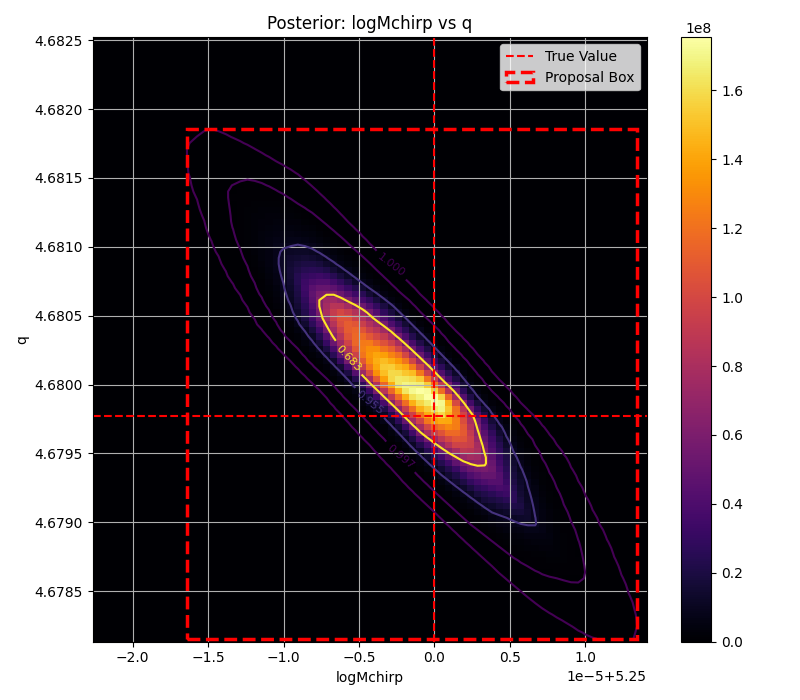

In [32]:
# Example: Plot the first available 2D marginal
if available_marginals:
    # Get the first marginal
    marginal_name, (in_param_idx, out_param_idx) = available_marginals[0]
    
    print(f"Plotting: {marginal_name}")
    
    fig, ax, boxes, levels, labels = plot_posterior_2d(
        dataloader_obs,
        model,
        in_param_idx=in_param_idx,
        out_param_idx=out_param_idx,
        ngrid_points=100,  # Adjust as needed
        show_diagnostics=True
    )
    
    plt.show()
else:
    print("No 2D marginals available to plot!")

## 7b. Generate Corner Plot with 1D Marginals

This creates a corner plot showing the 2D posterior along with the 1D marginals computed by integrating over the other parameter.

Plotting corner plot for: logMchirp vs q
Computing logratios on 100x100 grid...


100%|██████████| 1/1 [00:00<00:00,  1.99it/s]


Marginal normalization check:
  Marginal 0 integral: 1.000000
  Marginal 1 integral: 1.000000
Corner plot generated successfully! Grid: 100x100


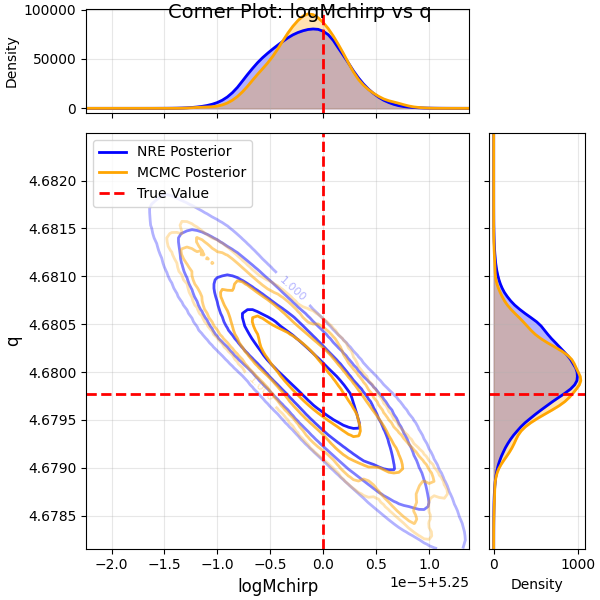


Available data keys: dict_keys(['grid_x', 'grid_y', 'grid_0', 'grid_1', 'norm2d', 'marginal_0', 'marginal_1', 'inj_params', 'levels', 'labels', 'boxes'])
1D marginal shapes: marginal_0=(100,), marginal_1=(100,)


In [33]:
# Generate corner plot for the first available 2D marginal
if available_marginals:
    # Get the first marginal
    marginal_name, (in_param_idx, out_param_idx) = available_marginals[0]
    
    print(f"Plotting corner plot for: {marginal_name}")
    
    # If results_mcmc is available, it will be automatically included
    fig, axs, data = plot_corner_with_marginals(
        dataloader_obs,
        model,
        in_param_idx=in_param_idx,
        out_param_idx=out_param_idx,
        ngrid_points=100,  # Adjust as needed
        show_diagnostics=True,
        results_mcmc=results_mcmc if 'results_mcmc' in globals() else None
    )
    
    plt.show()
    
    # You can access the data for further analysis:
    print(f"\nAvailable data keys: {data.keys()}")
    print(f"1D marginal shapes: marginal_0={data['marginal_0'].shape}, marginal_1={data['marginal_1'].shape}")
else:
    print("No 2D marginals available to plot!")

## 7c. Interactive Corner Plot Widget

Create an interactive corner plot with controls similar to the 2D plot widget.

## 7b2. MCMC Comparison Setup

To compare NRE posterior with MCMC results, you need a pandas DataFrame called `results_mcmc` with columns matching the parameter names in `_ORDERED_PRIOR_KEYS`:

```python
# Example: Load your MCMC samples
import pandas as pd
# results_mcmc = pd.read_csv('your_mcmc_samples.csv')
# or
# results_mcmc = pd.DataFrame({
#     'logMchirp': mcmc_samples[:, 0],
#     'q': mcmc_samples[:, 1],
#     # ... other parameters
# })
```

Once `results_mcmc` is defined, the corner plot will automatically:
- Show NRE contours in **blue** with varying alpha (darker = higher probability)
- Show MCMC contours in **orange** with varying alpha
- Compare 1D marginals in the side panels
- Remove the colormap background (white background with contours only)

**Note:** The colormap can be re-enabled for debugging by setting `show_colormap=True` when calling utility functions.

In [16]:
def create_interactive_corner_plot(results_mcmc=None):
    """
    Create an interactive corner plot with widgets to control grid resolution and parameter selection.
    
    Parameters:
    -----------
    results_mcmc : pd.DataFrame, optional
        DataFrame with MCMC samples (columns = parameter names from _ORDERED_PRIOR_KEYS)
    """
    # Output widget to hold the plot
    output = Output()
    
    # Storage for the latest results (for inspection)
    corner_results = {}
    
    # Widgets for parameter selection
    marginal_dropdown = Dropdown(
        options=available_marginals,
        description='Marginal:',
        style={'description_width': 'initial'}
    )
    
    # Grid resolution slider
    grid_slider = IntSlider(
        value=50,
        min=20,
        max=200,
        step=10,
        description='Grid Points:',
        continuous_update=False,
        style={'description_width': 'initial'}
    )
    
    # Checkboxes for custom bounds
    use_custom_bounds = widgets.Checkbox(
        value=False,
        description='Use Custom Bounds',
        style={'description_width': 'initial'}
    )
    
    # Checkbox for diagnostics
    show_diagnostics = widgets.Checkbox(
        value=True,
        description='Show Diagnostics',
        style={'description_width': 'initial'}
    )
    
    # Bounds inputs
    bound_0_min = FloatText(
        value=0,
        description='Param 1 Min:',
        style={'description_width': 'initial'}
    )
    bound_0_max = FloatText(
        value=1,
        description='Param 1 Max:',
        style={'description_width': 'initial'}
    )
    bound_1_min = FloatText(
        value=0,
        description='Param 2 Min:',
        style={'description_width': 'initial'}
    )
    bound_1_max = FloatText(
        value=1,
        description='Param 2 Max:',
        style={'description_width': 'initial'}
    )
    
    # Update button
    update_button = widgets.Button(
        description='Update Corner Plot',
        button_style='success',
        icon='refresh'
    )
    
    def update_bounds_inputs(change):
        """Update bounds inputs based on selected marginal."""
        in_param_idx, _ = marginal_dropdown.value
        prior_dict = model.hparams["dataset_info"]["conf"]["prior"]
        
        bounds_0 = prior_dict[_ORDERED_PRIOR_KEYS[in_param_idx[0]]]
        bounds_1 = prior_dict[_ORDERED_PRIOR_KEYS[in_param_idx[1]]]
        
        # Update parameter labels
        param_0_name = _ORDERED_PRIOR_KEYS[in_param_idx[0]]
        param_1_name = _ORDERED_PRIOR_KEYS[in_param_idx[1]]
        
        bound_0_min.description = f'{param_0_name} Min:'
        bound_0_max.description = f'{param_0_name} Max:'
        bound_1_min.description = f'{param_1_name} Min:'
        bound_1_max.description = f'{param_1_name} Max:'
        
        # Set default values to prior bounds
        bound_0_min.value = bounds_0[0]
        bound_0_max.value = bounds_0[1]
        bound_1_min.value = bounds_1[0]
        bound_1_max.value = bounds_1[1]
    
    def on_update_clicked(b):
        """Update the plot when button is clicked."""
        with output:
            output.clear_output(wait=True)
            
            # Get current settings
            in_param_idx, out_param_idx = marginal_dropdown.value
            ngrid = grid_slider.value
            
            # Get bounds
            if use_custom_bounds.value:
                bounds_0 = (bound_0_min.value, bound_0_max.value)
                bounds_1 = (bound_1_min.value, bound_1_max.value)
                
                # Validate bounds
                if bounds_0[0] >= bounds_0[1]:
                    print(f"Error: Param 1 Min ({bounds_0[0]}) must be less than Param 1 Max ({bounds_0[1]})")
                    return
                if bounds_1[0] >= bounds_1[1]:
                    print(f"Error: Param 2 Min ({bounds_1[0]}) must be less than Param 2 Max ({bounds_1[1]})")
                    return
                
                print(f"Using custom bounds:")
                print(f"  {_ORDERED_PRIOR_KEYS[in_param_idx[0]]}: [{bounds_0[0]:.4f}, {bounds_0[1]:.4f}]")
                print(f"  {_ORDERED_PRIOR_KEYS[in_param_idx[1]]}: [{bounds_1[0]:.4f}, {bounds_1[1]:.4f}]")
            else:
                bounds_0 = None
                bounds_1 = None
            
            # Generate corner plot
            fig, axs, data = plot_corner_with_marginals(
                dataloader_obs,
                model,
                in_param_idx=in_param_idx,
                out_param_idx=out_param_idx,
                ngrid_points=ngrid,
                bounds_0=bounds_0,
                bounds_1=bounds_1,
                figsize=(6, 6),
                show_diagnostics=show_diagnostics.value,
                results_mcmc=results_mcmc
            )
            
            # Store results for later inspection
            corner_results['fig'] = fig
            corner_results['axs'] = axs
            corner_results['data'] = data
            corner_results['in_param_idx'] = in_param_idx
            corner_results['out_param_idx'] = out_param_idx
            corner_results['ngrid_points'] = ngrid
            corner_results['bounds_0'] = bounds_0
            corner_results['bounds_1'] = bounds_1
            
            # Figure automatically displays in the Output widget, no need for plt.show()
    
    # Connect observers
    marginal_dropdown.observe(update_bounds_inputs, names='value')
    update_button.on_click(on_update_clicked)
    
    # Initialize bounds inputs
    if available_marginals:
        update_bounds_inputs(None)
    
    # Layout
    bounds_box = VBox([
        use_custom_bounds,
        HBox([bound_0_min, bound_0_max]),
        HBox([bound_1_min, bound_1_max])
    ])
    
    controls = VBox([
        marginal_dropdown,
        grid_slider,
        show_diagnostics,
        bounds_box,
        update_button
    ])
    
    display(controls, output)
    
    # Initial plot
    if available_marginals:
        on_update_clicked(None)
    
    return corner_results

print("Interactive corner plot function created!")

Interactive corner plot function created!


Output()

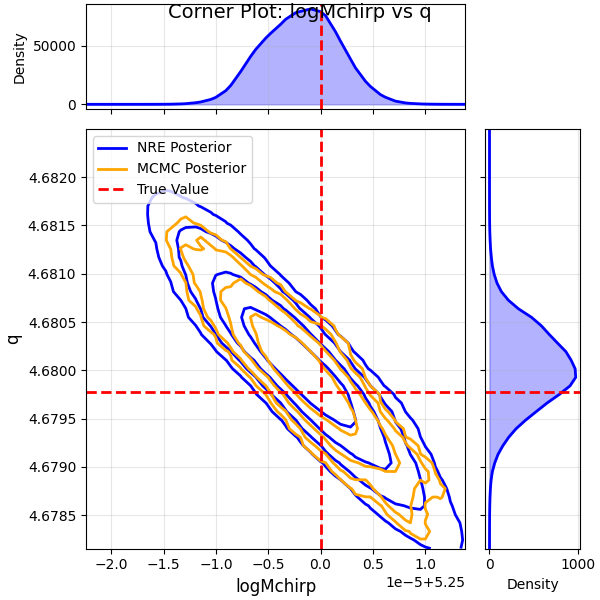

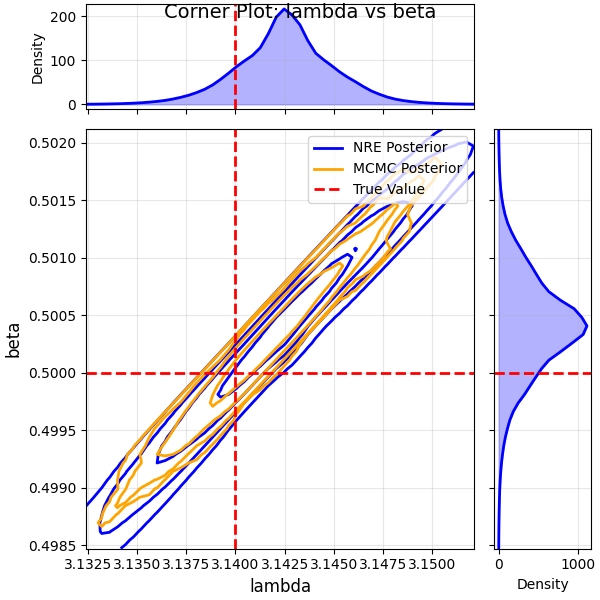

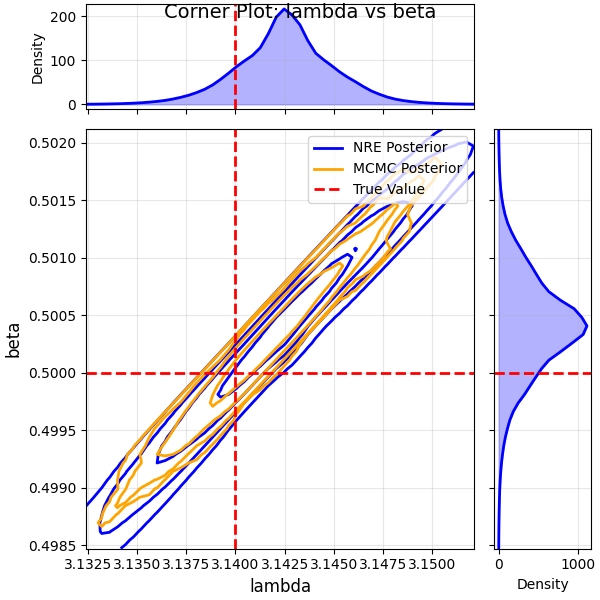

In [17]:
# Launch the interactive corner plot visualization
# If you have a results_mcmc DataFrame with MCMC samples, pass it here:
# corner_results = create_interactive_corner_plot(results_mcmc=results_mcmc)
# Otherwise, run without MCMC comparison:
filename = "/u/g/gpuleo/pembhb/mc_results/bbhx_event_0_bilbymcmc_resume.pickle"
import pickle 
with open(filename, 'rb') as f:
    resume_data = pickle.load(f)
results_mcmc = resume_data.samples 
corner_results = create_interactive_corner_plot(results_mcmc=results_mcmc if 'results_mcmc' in globals() else None)

## 7d. Analyze 1D Marginals

Access and analyze the 1D marginal distributions computed from the 2D posterior.

In [ ]:
# After running the corner plot, you can analyze the marginals
if 'data' in corner_results and corner_results['data'] is not None:
    data = corner_results['data']
    in_param_idx = corner_results['in_param_idx']
    
    param_name_0 = _ORDERED_PRIOR_KEYS[in_param_idx[0]]
    param_name_1 = _ORDERED_PRIOR_KEYS[in_param_idx[1]]
    
    # Compute statistics for marginal 0
    grid_0 = data['grid_0']
    marginal_0 = data['marginal_0']
    dp1 = grid_0[1] - grid_0[0]
    
    # Find peak (MAP)
    idx_max_0 = np.argmax(marginal_0)
    map_0 = grid_0[idx_max_0]
    
    # Compute mean
    mean_0 = np.sum(grid_0 * marginal_0 * dp1)
    
    # Compute std
    var_0 = np.sum((grid_0 - mean_0)**2 * marginal_0 * dp1)
    std_0 = np.sqrt(var_0)
    
    # Compute statistics for marginal 1
    grid_1 = data['grid_1']
    marginal_1 = data['marginal_1']
    dp2 = grid_1[1] - grid_1[0]
    
    idx_max_1 = np.argmax(marginal_1)
    map_1 = grid_1[idx_max_1]
    
    mean_1 = np.sum(grid_1 * marginal_1 * dp2)
    var_1 = np.sum((grid_1 - mean_1)**2 * marginal_1 * dp2)
    std_1 = np.sqrt(var_1)
    
    print(f"=== 1D Marginal Statistics ===\n")
    
    print(f"{param_name_0}:")
    print(f"  MAP (mode):  {map_0:.6f}")
    print(f"  Mean:        {mean_0:.6f}")
    print(f"  Std:         {std_0:.6f}")
    print(f"  True value:  {data['inj_params'][0]:.6f}")
    print()
    
    print(f"{param_name_1}:")
    print(f"  MAP (mode):  {map_1:.6f}")
    print(f"  Mean:        {mean_1:.6f}")
    print(f"  Std:         {std_1:.6f}")
    print(f"  True value:  {data['inj_params'][1]:.6f}")
    
else:
    print("Run the corner plot first to analyze marginals!")

---

## Summary: Corner Plot Features

The corner plot functionality provides:

### Mathematical Details:
- **2D Posterior**: $p(\theta_1, \theta_2 | d)$ evaluated on a grid
- **1D Marginals**: Computed by numerical integration (summation):
  - $p(\theta_1 | d) = \int p(\theta_1, \theta_2 | d) d\theta_2$
  - $p(\theta_2 | d) = \int p(\theta_1, \theta_2 | d) d\theta_1$

### Layout:
```
┌─────────────┬─────┐
│  1D marg θ₁ │     │
├─────────────┼─────┤
│  2D post    │ 1D  │
│  θ₁ vs θ₂   │marg │
│             │ θ₂  │
└─────────────┴─────┘
```

### Features:
- ✅ Analytical posterior evaluated on grid (no MCMC needed)
- ✅ 1D marginals computed by summing over grid points with proper normalization
- ✅ Contour lines showing credible regions (68%, 95%, etc.)
- ✅ True parameter values marked with red dashed lines
- ✅ Interactive widgets for real-time parameter exploration
- ✅ Statistical summaries (MAP, mean, std) for each marginal

### Usage:
1. Use `plot_corner_with_marginals()` for a single static corner plot
2. Use `create_interactive_corner_plot()` for interactive exploration
3. Access `corner_results['data']` to get marginals and grid data for further analysis

This is particularly useful for:
- Understanding posterior structure without running MCMC
- Debugging grid resolution effects on marginals
- Comparing with traditional sampling-based corner plots

## 8. Analyze Widest Box Dependency on Grid Resolution

This section helps debug how the widest box (used for prior updating in TMNRE) changes with different grid resolutions.

In [ ]:
def compare_boxes_across_grids(dataloader, model, in_param_idx, out_param_idx, 
                                grid_resolutions=[30, 50, 75, 100, 150],
                                bounds_0=None, bounds_1=None):
    """
    Compare how the widest box changes with different grid resolutions.
    
    This is useful for understanding the stability of the prior updating procedure.
    """
    param_name_0 = _ORDERED_PRIOR_KEYS[in_param_idx[0]]
    param_name_1 = _ORDERED_PRIOR_KEYS[in_param_idx[1]]
    
    print(f"Comparing widest boxes for {param_name_0} vs {param_name_1}")
    print(f"=" * 80)
    
    results = []
    
    for ngrid in grid_resolutions:
        print(f"\nGrid resolution: {ngrid}x{ngrid}")
        print("-" * 40)
        
        # Compute without plotting (faster)
        logratios, inj_params, gx, gy = get_logratios_grid_2d(
            dataloader,
            model,
            ngrid_points=ngrid,
            in_param_idx=in_param_idx,
            out_param_idx=out_param_idx,
            bounds_0=bounds_0,
            bounds_1=bounds_1
        )
        
        # Convert to ratios and normalize
        # With xy indexing: gx varies along columns (axis 1), gy varies along rows (axis 0)
        ratios = np.exp(logratios)
        dp1 = gx[0, 1] - gx[0, 0]  # param_0 spacing (x varies along columns)
        dp2 = gy[1, 0] - gy[0, 0]  # param_1 spacing (y varies along rows)
        norm2d = ratios / np.sum(ratios * dp1 * dp2, axis=(1, 2), keepdims=True)
        
        # Compute contour levels
        levels, labels = contour_levels(norm2d)
        
        # Get boxes using posterior_contours_2d
        boxes = posterior_contours_2d(
            gx, gy, norm2d[0], inj_params[0],
            ax_buffer=None,
            parameter_names=[param_name_0, param_name_1],
            levels=levels,
            levels_labels=labels,
            do_plot=False
        )
        
        # Extract widest box
        widest_box = boxes[0]
        
        print(f"  Widest box (outermost contour):")
        print(f"    {param_name_0}: [{widest_box[0]:.6f}, {widest_box[1]:.6f}] (width: {widest_box[1]-widest_box[0]:.6f})")
        print(f"    {param_name_1}: [{widest_box[2]:.6f}, {widest_box[3]:.6f}] (width: {widest_box[3]-widest_box[2]:.6f})")
        
        results.append({
            'ngrid': ngrid,
            'boxes': boxes,
            'levels': levels,
            'labels': labels,
            'widest_box': widest_box,
            'param_0_bounds': (widest_box[0], widest_box[1]),
            'param_1_bounds': (widest_box[2], widest_box[3]),
            'param_0_width': widest_box[1] - widest_box[0],
            'param_1_width': widest_box[3] - widest_box[2]
        })
    
    # Summary comparison
    print(f"\n{'=' * 80}")
    print("SUMMARY: Variation in widest box across grid resolutions")
    print(f"{'=' * 80}")
    
    # Analyze parameter 0
    param_0_mins = [r['param_0_bounds'][0] for r in results]
    param_0_maxs = [r['param_0_bounds'][1] for r in results]
    param_0_widths = [r['param_0_width'] for r in results]
    
    print(f"\n{param_name_0}:")
    print(f"  Min bounds range: [{min(param_0_mins):.6f}, {max(param_0_mins):.6f}] (variation: {max(param_0_mins)-min(param_0_mins):.6e})")
    print(f"  Max bounds range: [{min(param_0_maxs):.6f}, {max(param_0_maxs):.6f}] (variation: {max(param_0_maxs)-min(param_0_maxs):.6e})")
    print(f"  Width range: [{min(param_0_widths):.6f}, {max(param_0_widths):.6f}] (variation: {max(param_0_widths)-min(param_0_widths):.6e})")
    
    # Analyze parameter 1
    param_1_mins = [r['param_1_bounds'][0] for r in results]
    param_1_maxs = [r['param_1_bounds'][1] for r in results]
    param_1_widths = [r['param_1_width'] for r in results]
    
    print(f"\n{param_name_1}:")
    print(f"  Min bounds range: [{min(param_1_mins):.6f}, {max(param_1_mins):.6f}] (variation: {max(param_1_mins)-min(param_1_mins):.6e})")
    print(f"  Max bounds range: [{min(param_1_maxs):.6f}, {max(param_1_maxs):.6f}] (variation: {max(param_1_maxs)-min(param_1_maxs):.6e})")
    print(f"  Width range: [{min(param_1_widths):.6f}, {max(param_1_widths):.6f}] (variation: {max(param_1_widths)-min(param_1_widths):.6e})")
    
    return results

print("Box comparison function created!")

Box comparison function created!


In [12]:
# Run the comparison for the first available marginal
if available_marginals:
    marginal_name, (in_param_idx, out_param_idx) = available_marginals[0]
    
    print(f"Analyzing: {marginal_name}\n")
    
    grid_comparison_results = compare_boxes_across_grids(
        dataloader_obs,
        model,
        in_param_idx=in_param_idx,
        out_param_idx=out_param_idx,
        grid_resolutions=[30, 50, 75, 100, 150]
    )
else:
    print("No 2D marginals available!")

Analyzing: logMchirp vs q

Comparing widest boxes for logMchirp vs q

Grid resolution: 30x30
----------------------------------------


100%|██████████| 1/1 [00:00<00:00, 18.72it/s]


  Widest box (outermost contour):
    logMchirp: [5.249983, 5.250014] (width: 0.000030)
    q: [4.678155, 4.681877] (width: 0.003721)

Grid resolution: 50x50
----------------------------------------


100%|██████████| 1/1 [00:00<00:00,  7.46it/s]


  Widest box (outermost contour):
    logMchirp: [5.249983, 5.250014] (width: 0.000030)
    q: [4.678155, 4.681865] (width: 0.003709)

Grid resolution: 75x75
----------------------------------------


...

  Widest box (outermost contour):
    logMchirp: [5.249984, 5.250013] (width: 0.000030)
    q: [4.678155, 4.681853] (width: 0.003698)

Grid resolution: 100x100
----------------------------------------


100%|██████████| 1/1 [00:00<00:00,  1.87it/s]


  Widest box (outermost contour):
    logMchirp: [5.249984, 5.250013] (width: 0.000030)
    q: [4.678155, 4.681855] (width: 0.003700)

Grid resolution: 150x150
----------------------------------------


100%|██████████| 1/1 [00:01<00:00,  1.19s/it]

  Widest box (outermost contour):
    logMchirp: [5.249984, 5.250013] (width: 0.000030)
    q: [4.678155, 4.681848] (width: 0.003692)

SUMMARY: Variation in widest box across grid resolutions

logMchirp:
  Min bounds range: [5.249983, 5.249984] (variation: 3.250751e-07)
  Max bounds range: [5.250013, 5.250014] (variation: 2.695165e-07)
  Width range: [0.000030, 0.000030] (variation: 5.945916e-07)

q:
  Min bounds range: [4.678155, 4.678155] (variation: 0.000000e+00)
  Max bounds range: [4.681848, 4.681877] (variation: 2.924772e-05)
  Width range: [0.003692, 0.003721] (variation: 2.924772e-05)


## 9. Visualize Box Variation Across Grid Resolutions

Plot how the widest box bounds change with grid resolution.

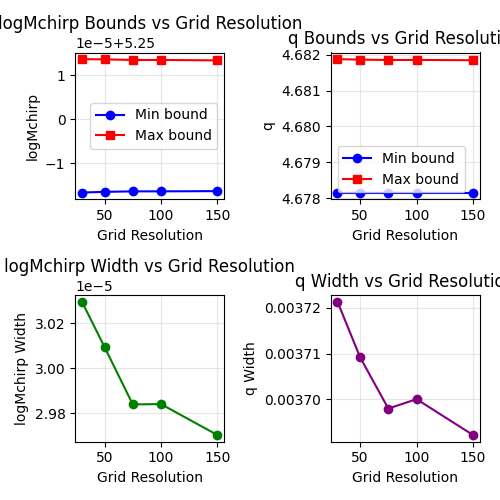

In [13]:
def plot_box_variation(results, in_param_idx):
    """
    Plot how the widest box bounds vary with grid resolution.
    """
    param_name_0 = _ORDERED_PRIOR_KEYS[in_param_idx[0]]
    param_name_1 = _ORDERED_PRIOR_KEYS[in_param_idx[1]]
    
    ngrids = [r['ngrid'] for r in results]
    param_0_mins = [r['param_0_bounds'][0] for r in results]
    param_0_maxs = [r['param_0_bounds'][1] for r in results]
    param_1_mins = [r['param_1_bounds'][0] for r in results]
    param_1_maxs = [r['param_1_bounds'][1] for r in results]
    
    fig, axes = plt.subplots(2, 2, figsize=(5, 5))
    
    # Parameter 0 bounds
    ax = axes[0, 0]
    ax.plot(ngrids, param_0_mins, 'o-', label='Min bound', color='blue')
    ax.plot(ngrids, param_0_maxs, 's-', label='Max bound', color='red')
    ax.set_xlabel('Grid Resolution')
    ax.set_ylabel(f'{param_name_0}')
    ax.set_title(f'{param_name_0} Bounds vs Grid Resolution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Parameter 1 bounds
    ax = axes[0, 1]
    ax.plot(ngrids, param_1_mins, 'o-', label='Min bound', color='blue')
    ax.plot(ngrids, param_1_maxs, 's-', label='Max bound', color='red')
    ax.set_xlabel('Grid Resolution')
    ax.set_ylabel(f'{param_name_1}')
    ax.set_title(f'{param_name_1} Bounds vs Grid Resolution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Parameter 0 width
    ax = axes[1, 0]
    param_0_widths = [r['param_0_width'] for r in results]
    ax.plot(ngrids, param_0_widths, 'o-', color='green')
    ax.set_xlabel('Grid Resolution')
    ax.set_ylabel(f'{param_name_0} Width')
    ax.set_title(f'{param_name_0} Width vs Grid Resolution')
    ax.grid(True, alpha=0.3)
    
    # Parameter 1 width
    ax = axes[1, 1]
    param_1_widths = [r['param_1_width'] for r in results]
    ax.plot(ngrids, param_1_widths, 'o-', color='purple')
    ax.set_xlabel('Grid Resolution')
    ax.set_ylabel(f'{param_name_1} Width')
    ax.set_title(f'{param_name_1} Width vs Grid Resolution')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Plot the variation if results are available
if 'grid_comparison_results' in globals() and grid_comparison_results:
    if available_marginals:
        _, (in_param_idx, _) = available_marginals[0]
        plot_box_variation(grid_comparison_results, in_param_idx)
else:
    print("Run the grid comparison cell first!")

## 10. Inspect Latest Plot Results

Access the results from the most recent interactive plot.

In [17]:
# Access the results from the interactive plot
if 'plot_results' in globals() and plot_results:
    print("Latest interactive plot results:")
    print(f"  Grid points: {plot_results.get('ngrid_points', 'N/A')}")
    print(f"  Parameters: {_ORDERED_PRIOR_KEYS[plot_results['in_param_idx'][0]]} vs {_ORDERED_PRIOR_KEYS[plot_results['in_param_idx'][1]]}")
    
    if plot_results['boxes'] is not None:
        widest_box = plot_results['boxes'][-1]
        print(f"\n  Widest box:")
        print(f"    {_ORDERED_PRIOR_KEYS[plot_results['in_param_idx'][0]]}: [{widest_box[0]:.6f}, {widest_box[1]:.6f}]")
        print(f"    {_ORDERED_PRIOR_KEYS[plot_results['in_param_idx'][1]]}: [{widest_box[2]:.6f}, {widest_box[3]:.6f}]")
        
        print(f"\n  All {len(plot_results['boxes'])} contour levels:")
        for i, (box, level, label) in enumerate(zip(plot_results['boxes'], plot_results['levels'], plot_results['labels'])):
            print(f"    Level {i}: prob={label:.4f}, {_ORDERED_PRIOR_KEYS[plot_results['in_param_idx'][0]]}=[{box[0]:.6f}, {box[1]:.6f}], {_ORDERED_PRIOR_KEYS[plot_results['in_param_idx'][1]]}=[{box[2]:.6f}, {box[3]:.6f}]")
    else:
        print("  No boxes available (plotting may have failed)")
else:
    print("No plot results available yet. Run the interactive plot first!")

Latest interactive plot results:
  Grid points: 50
  Parameters: logMchirp vs q

  Widest box:
    logMchirp: [5.248247, 5.249712]
    q: [4.670242, 4.705102]

  All 4 contour levels:
    Level 0: prob=0.9999, logMchirp=[5.244996, 5.252296], q=[4.650000, 4.750000]
    Level 1: prob=0.9973, logMchirp=[5.246964, 5.250995], q=[4.650000, 4.745918]
    Level 2: prob=0.9545, logMchirp=[5.247261, 5.250698], q=[4.654082, 4.724991]
    Level 3: prob=0.6827, logMchirp=[5.248247, 5.249712], q=[4.670242, 4.705102]


## 11. Debug: Inspect Contour Details

Extract and visualize individual contour paths to understand how boxes are computed.

In [ ]:
def inspect_contour_details(dataloader, model, in_param_idx, out_param_idx, 
                            ngrid_points=100, bounds_0=None, bounds_1=None):
    """
    Generate contours and inspect their detailed structure.
    
    This helps debug issues with contour extraction and box computation.
    """
    from pembhb.utils import contour_boxes
    
    param_name_0 = _ORDERED_PRIOR_KEYS[in_param_idx[0]]
    param_name_1 = _ORDERED_PRIOR_KEYS[in_param_idx[1]]
    
    # Get logratios on grid
    print(f"Computing logratios on {ngrid_points}x{ngrid_points} grid...")
    logratios, inj_params, gx, gy = get_logratios_grid_2d(
        dataloader,
        model,
        ngrid_points=ngrid_points,
        in_param_idx=in_param_idx,
        out_param_idx=out_param_idx,
        bounds_0=bounds_0,
        bounds_1=bounds_1
    )
    
    # Convert to ratios and normalize
    # With xy indexing: gx varies along columns (axis 1), gy varies along rows (axis 0)
    ratios = np.exp(logratios)
    dp1 = gx[0, 1] - gx[0, 0]  # param_0 spacing (x varies along columns)
    dp2 = gy[1, 0] - gy[0, 0]  # param_1 spacing (y varies along rows)
    norm2d = ratios / np.sum(ratios * dp1 * dp2, axis=(1, 2), keepdims=True)
    
    # Compute contour levels
    levels, labels = contour_levels(norm2d)
    
    print(f"\nContour levels: {levels}")
    print(f"Probability labels: {labels}")
    
    # Create contours
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    boxes, cs = contour_boxes(gx, gy, norm2d[0], levels, ax=ax)
    
    # Add labels and styling
    fmt = {lev: f"{p:.3f}" for lev, p in zip(levels, labels)}
    ax.clabel(cs, fmt=fmt, fontsize=10)
    ax.set_xlabel(param_name_0)
    ax.set_ylabel(param_name_1)
    ax.set_title(f"Contours: {param_name_0} vs {param_name_1}")
    ax.grid(True, alpha=0.3)
    
    # Mark injection point
    ax.plot(inj_params[0][0], inj_params[0][1], 'r*', markersize=15, label='True Value')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed info about each contour
    print(f"\n{'=' * 80}")
    print("CONTOUR DETAILS")
    print(f"{'=' * 80}")
    
    for i, (collection, level, label, box) in enumerate(zip(cs.collections, levels, labels, boxes)):
        paths = collection.get_paths()
        print(f"\nLevel {i}: probability={label:.4f}, level_value={level:.6e}")
        print(f"  Number of contour segments: {len(paths)}")
        print(f"  Bounding box: {param_name_0}=[{box[0]:.6f}, {box[1]:.6f}], {param_name_1}=[{box[2]:.6f}, {box[3]:.6f}]")
        
        # Show details of each segment
        for path_idx, path in enumerate(paths):
            vertices = path.vertices
            print(f"    Segment {path_idx}: {len(vertices)} vertices")
            print(f"      {param_name_0} range: [{vertices[:, 0].min():.6f}, {vertices[:, 0].max():.6f}]")
            print(f"      {param_name_1} range: [{vertices[:, 1].min():.6f}, {vertices[:, 1].max():.6f}]")
    
    return fig, ax, boxes, levels, labels, cs

print("Contour inspection function created!")

Contour inspection function created!


Inspecting contours for: logMchirp vs q

Computing logratios on 100x100 grid...


100%|██████████| 1/1 [00:00<00:00,  1.87it/s]


Contour levels: [2.0786498e+04 5.0376619e+05 9.0933110e+06 6.2458664e+07]
Probability labels: [0.9999 0.9973 0.9545 0.6827]


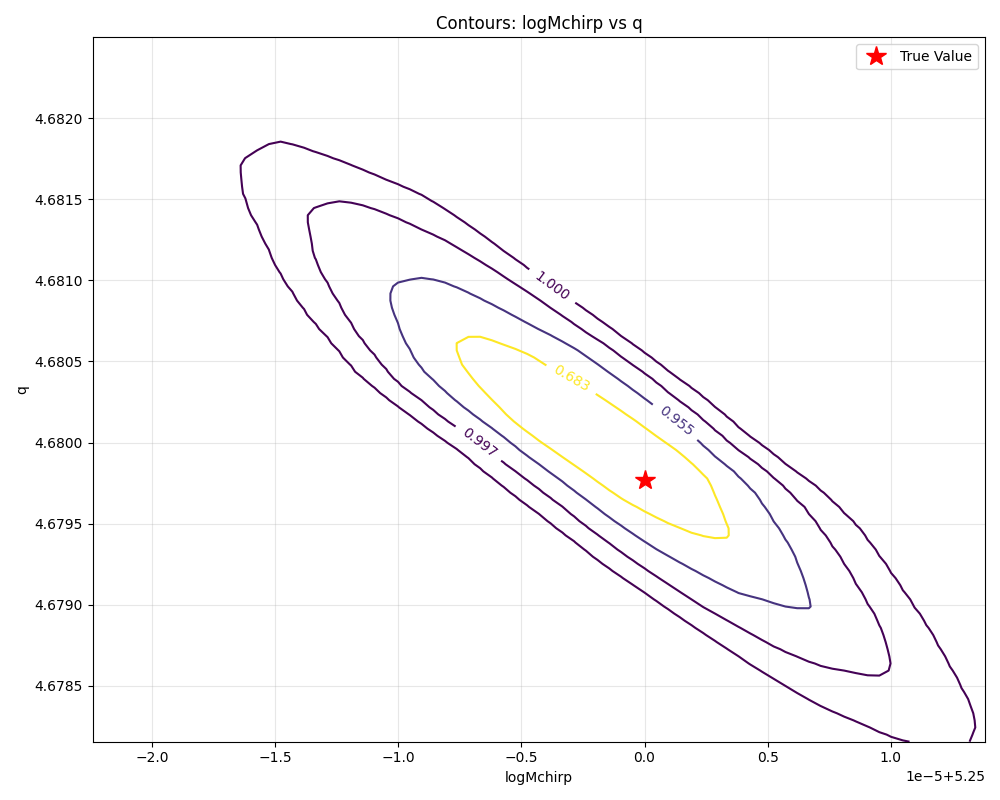


CONTOUR DETAILS


AttributeError: 'QuadContourSet' object has no attribute 'collections'

In [16]:
# Example: Inspect contours for the first marginal
if available_marginals:
    marginal_name, (in_param_idx, out_param_idx) = available_marginals[0]
    
    print(f"Inspecting contours for: {marginal_name}\n")
    
    fig, ax, boxes, levels, labels, cs = inspect_contour_details(
        dataloader_obs,
        model,
        in_param_idx=in_param_idx,
        out_param_idx=out_param_idx,
        ngrid_points=100
    )
else:
    print("No 2D marginals available!")

---

## Summary

This notebook provides comprehensive tools for debugging posterior visualization and the widest box computation used in PlotPosteriorCallback:

### Key Features:

1. **Interactive Visualization (Section 6)**: 
   - Adjust grid resolution on the fly
   - Set custom bounds for zooming into specific regions
   - Toggle diagnostic output
   - Access results via `plot_results` dictionary

2. **Widest Box Diagnostics (Section 4)**:
   - Shows all contour levels and their bounding boxes
   - Highlights the widest box used for prior updating in TMNRE
   - Displays probability levels for each contour

3. **Grid Resolution Analysis (Section 8-9)**:
   - Compare how widest box changes across different grid resolutions
   - Visualize the stability/variation of the bounds
   - Helps identify if grid resolution is affecting prior updates

4. **Contour Details (Section 11)**:
   - Inspect individual contour segments
   - Understand how bounding boxes are computed from contour paths
   - Debug issues with contour extraction

### Debugging Workflow:

1. Run the interactive plot (Section 6) with different grid resolutions
2. Check the diagnostic output to see all boxes and levels
3. Compare boxes across resolutions (Section 8) to check stability
4. If issues persist, inspect contour details (Section 11) to see the raw contour paths

### Common Issues:

- **True value out of place**: Check if custom bounds are correctly set for both parameters
- **Mismatched xlim/ylim**: Verify that `bounds_0` and `bounds_1` are in the correct order
- **Unstable boxes**: Compare across grid resolutions to see if higher resolution helps
- **Grid resolution dependence**: Use Section 8-9 to quantify how much boxes vary with grid size

In [29]:
# Extract contour lines from the plot
contour_lines = ax.collections

# Print the number of contour lines
print(f"Number of contour lines: {len(contour_lines)}")
# Example: Inspect the first contour line
first_contour = contour_lines[0]
print(f"First contour line paths: {first_contour.get_paths()}")

Number of contour lines: 2
First contour line paths: [Path(array([[5.23989868, 4.64949512],
       [5.23989868, 4.65050507],
       [5.24010086, 4.65050507],
       [5.24010086, 4.64949512],
       [5.23989868, 4.64949512]]), None), Path(array([[5.23989868, 4.65050507],
       [5.23989868, 4.65151525],
       [5.24010086, 4.65151525],
       [5.24010086, 4.65050507],
       [5.23989868, 4.65050507]]), None), Path(array([[5.23989868, 4.65151525],
       [5.23989868, 4.65252542],
       [5.24010086, 4.65252542],
       [5.24010086, 4.65151525],
       [5.23989868, 4.65151525]]), None), Path(array([[5.23989868, 4.65252542],
       [5.23989868, 4.65353537],
       [5.24010086, 4.65353537],
       [5.24010086, 4.65252542],
       [5.23989868, 4.65252542]]), None), Path(array([[5.23989868, 4.65353537],
       [5.23989868, 4.65454555],
       [5.24010086, 4.65454555],
       [5.24010086, 4.65353537],
       [5.23989868, 4.65353537]]), None), Path(array([[5.23989868, 4.65454555],
       [5.239

In [30]:
first_contour

## Notes

**Key Features:**
- **Interactive Controls**: Use the dropdown to select different 2D marginals (parameter pairs) that the model was trained on
- **Grid Resolution**: Adjust the grid resolution from 20x20 to 200x200 points. Higher resolution gives smoother contours but takes longer to compute
- **Custom Bounds**: Enable custom bounds to zoom into specific regions of parameter space
- **Contour Lines**: The plot includes contour lines with labels showing confidence levels (68%, 95%, etc.)
- **True Values**: Red dashed lines show the true injected parameter values

**How the Plot Works:**
1. The model computes log-likelihood ratios on a 2D grid of parameter values
2. These are converted to normalized posterior probabilities
3. Contour levels are computed to show confidence regions
4. The colormap shows the posterior density, with warmer colors indicating higher probability

**Tips:**
- Start with a lower grid resolution (50-70) for faster iteration
- Increase grid resolution (100-150) for final publication-quality plots
- Use custom bounds to zoom into regions of interest
- The plot automatically updates when you click "Update Plot"

**Parameter Names:**
The parameter indices correspond to:
```
0: logMchirp  - Log chirp mass
1: q          - Mass ratio
2: chi1       - Primary spin
3: chi2       - Secondary spin
4: dist       - Distance
5: phi        - Orbital phase
6: inc        - Inclination
7: lambda     - Ecliptic longitude
8: beta       - Ecliptic latitude
9: psi        - Polarization angle
10: Deltat    - Time delay
```